This notebook contains additional model evaluation and compares model performance across sites and species.

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import zipfile

from matplotlib.ticker import AutoMinorLocator
from pathlib import Path
from scipy import stats

from ml_baselines.modelling.predict import predict_baselines
from ml_baselines.config import Config
from ml_baselines.data import read_agage
from ml_baselines.modelling.predict import load_baseline_model, BaselineLabelledObservations

cfg = Config()

import warnings
warnings.filterwarnings("ignore")

In [2]:
%load_ext autoreload
%autoreload 2
import warnings
warnings.filterwarnings("ignore")

## Coefficient of Variation

Loaded model from C:\Users\kirst\OneDrive\Kirstin\Uni\Year4\MSciProject\final_code\ml-baselines\models\MHD\mlp_model_2026-05-13_11-23_final.joblib


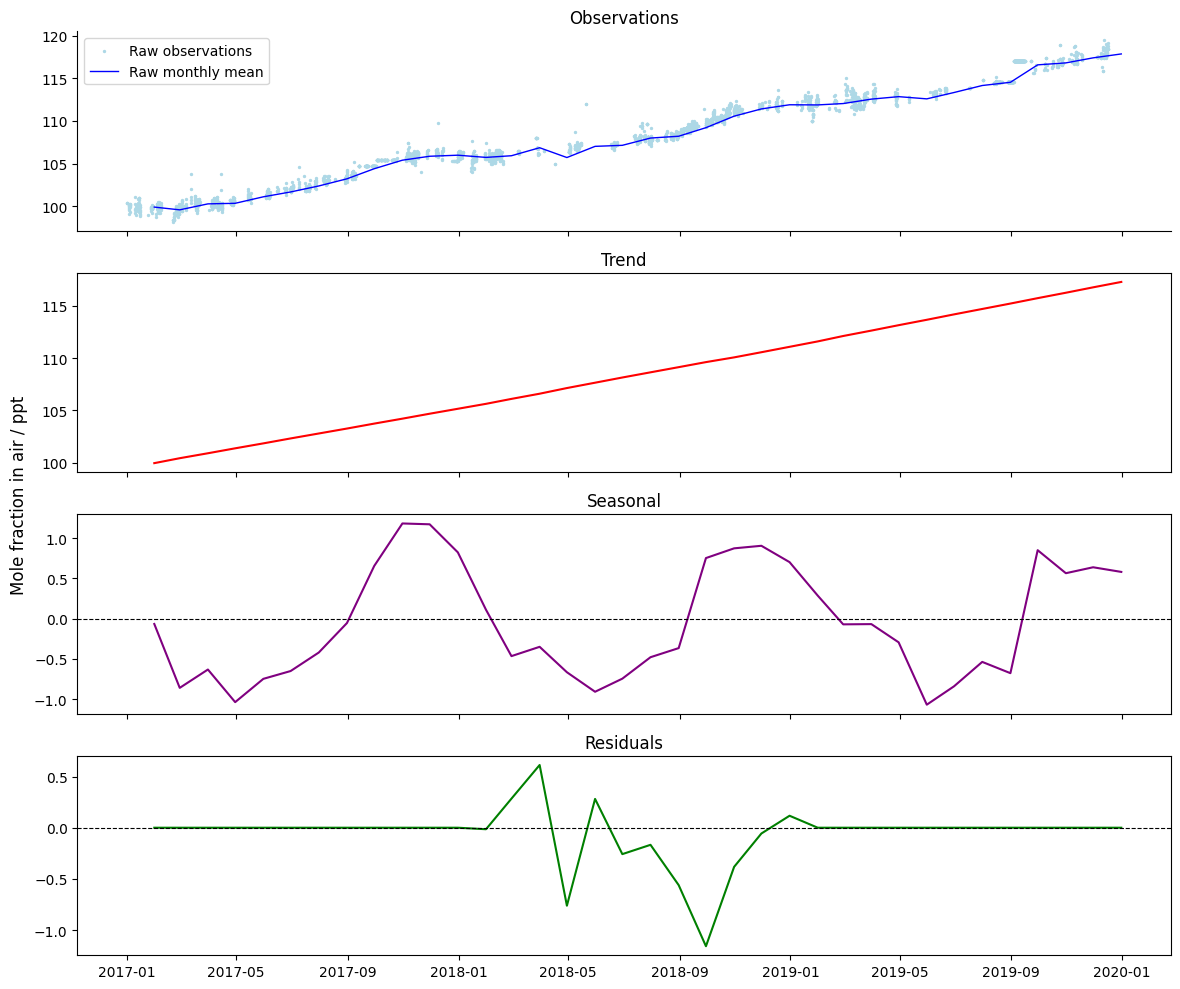

CV on train set for hfc-134a at MHD: 0.003


In [3]:
# explore one species
site = 'MHD'
species = 'hfc-134a'
model_type = cfg.model_type

model, extra_info = model, extra_info = load_baseline_model(site, model_type, timestamp=None, suffix="final")
scaler = extra_info['scaler']
threshold = extra_info['model_inputs']['prediction_threshold']
y, y_pred, y_proba, ymetrics = predict_baselines(site=site, 
                                                model=model, 
                                                scaler=scaler,
                                                prediction_mode="full", 
                                                prediction_threshold=threshold,
                                                return_proba=True,
                                                verbose=False)

df_agage = read_agage(site, species.lower(), start_year=cfg.testing_period[site][0], end_year=cfg.testing_period[site][1])
labelled_obs_species = BaselineLabelledObservations(y, y_pred, df_agage, species=species, site=site, y_proba=y_proba)
labelled_obs_species.calculate_true_baseline_cv(eval_mode="train", remove_seasonality=True, plot_stl=True, verbose=False) # plot seasonality decomposition as sanity check
print(f"CV on {labelled_obs_species.baseline_cv['eval_mode']} set for {species} at {site}: {labelled_obs_species.baseline_cv['cv']:.3f}")

In [4]:
# loop through sites and species
sites = list(cfg.site_dict.keys())

cv_dict = {}
remove_seasonality = True
for site in sites:
    try:
        model, extra_info = model, extra_info = load_baseline_model(site, model_type, timestamp=None, suffix="final", verbose=False)
    except:
         print("")
         continue
    print(f"Processing {site}...")
    cv_dict[site] = {}
    scaler = extra_info['scaler']
    threshold = extra_info['model_inputs']['prediction_threshold']
    time_shift_hours = extra_info['model_inputs']['time_shift_hours']

    y, y_pred, y_proba, ymetrics = predict_baselines(site=site, 
                                                    model=model, 
                                                    scaler=scaler,
                                                    prediction_mode="full", 
                                                    prediction_threshold=threshold,
                                                    time_shift_hours=time_shift_hours,
                                                    return_proba=True,
                                                    verbose=False)

    with zipfile.ZipFile(Path(cfg.obs_path), 'r') as zf:
            all_files = zf.namelist()
            available = [(f.split('/')[1], f.split('_')[1].upper()) 
                        for f in all_files if f.endswith('.nc')]
            available_species = sorted(set([a[0] for a in available if a[1] == site.upper()]))

    num_low_coverage = 0
    print("   evaluating species...")
    for species in available_species:
        df_agage = read_agage(site, species.lower(), start_year=cfg.testing_period[site][0], end_year=cfg.testing_period[site][1])
        try:
            labelled_obs_species = BaselineLabelledObservations(y, y_pred, df_agage, species=species, site=site, y_proba=y_proba)
            labelled_obs_species.calculate_true_baseline_cv(eval_mode="train", remove_seasonality=remove_seasonality, verbose=False)
        except Exception as e:
            print(f"   {type(e).__name__}: {species}: {e}")
            continue
        cv_dict[site][species] = {}
        baseline_cv = labelled_obs_species.baseline_cv['cv']
        cv_dict[site][species]['cv'] = baseline_cv
        if labelled_obs_species.baseline_cv['pct_monthly_coverage'] < 75:
            num_low_coverage += 1

        labelled_obs_species.print_monthly_stats(verbose=False)
        mape = labelled_obs_species.monthly_scores["test"]["MAPE"]
        cv_dict[site][species]['mape'] = mape.item()

    if num_low_coverage > 0 and remove_seasonality==True: 
        print(f"   {num_low_coverage}/{len(available_species)} of species had low coverage.\n") 
    else:
        print("")

Processing MHD...
   evaluating species...
   ValueError: chclccl2: No data found for the train period (2017–2019). This may be because predictions were not made for this date range (note that eval_mode='train' or 'validation' require prediction_mode='full' in predict_baselines), or because there are no overlapping observations.

Processing RPB...
   evaluating species...

Processing CGO...
   evaluating species...
   ValueError: cfc-113: No data found for the train period (2017–2019). This may be because predictions were not made for this date range (note that eval_mode='train' or 'validation' require prediction_mode='full' in predict_baselines), or because there are no overlapping observations.

Processing GSN...
   evaluating species...

Processing JFJ...
   evaluating species...
   ValueError: chclccl2: No data found for the train period (2017–2019). This may be because predictions were not made for this date range (note that eval_mode='train' or 'validation' require prediction_mod

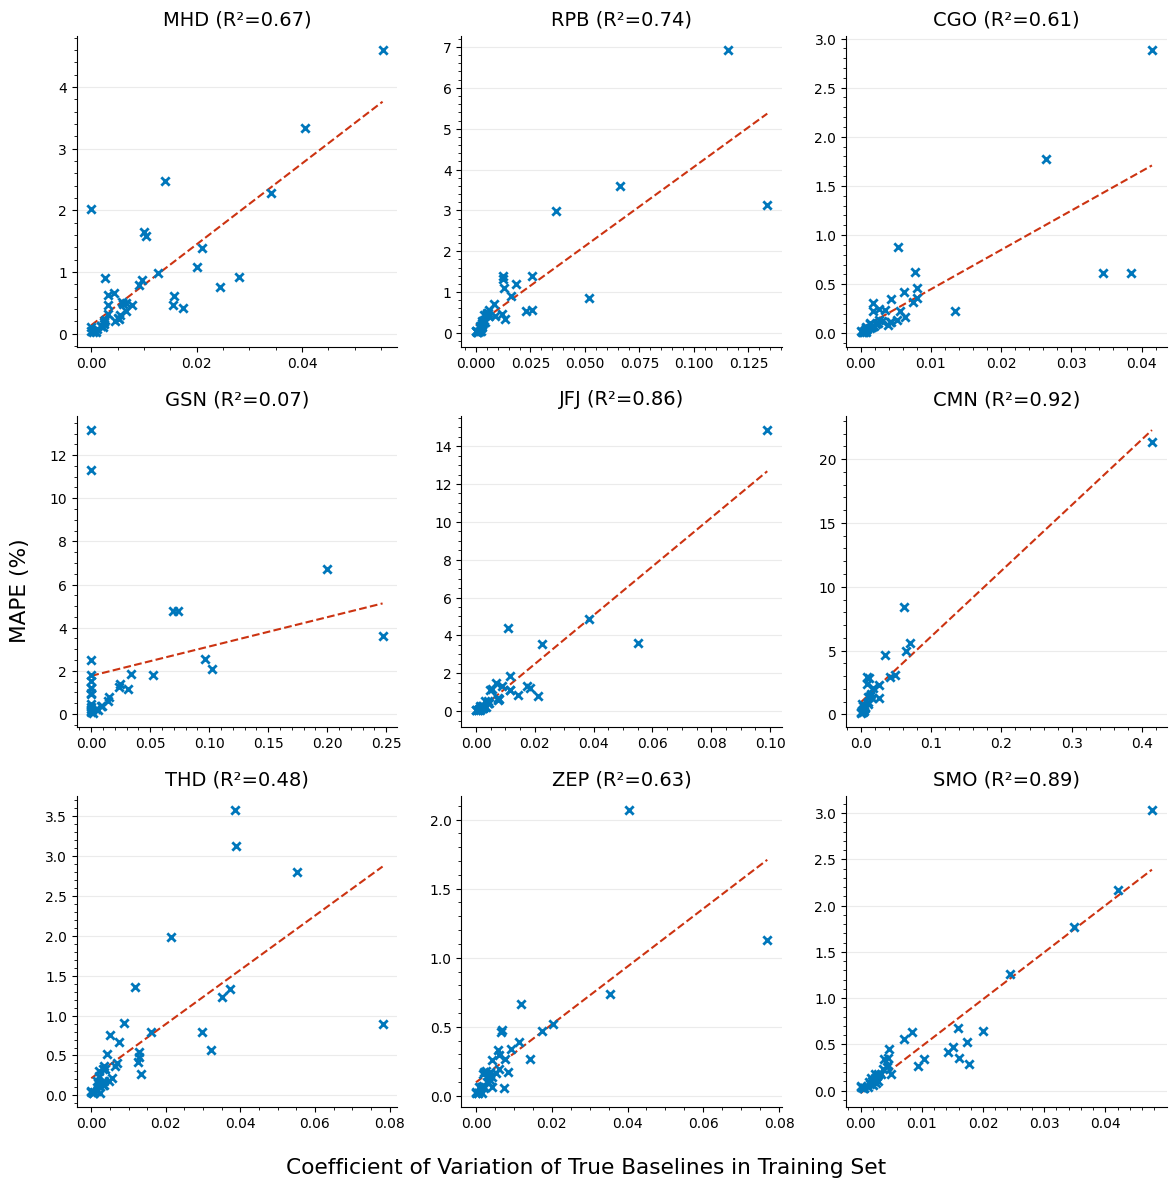

In [ ]:
# plot
fig, axes = plt.subplots(3, 3, figsize=(12,12))
plt.rcParams.update({
    'font.size': 13,
    'axes.titlesize': 13,
    'xtick.labelsize': 11,
    'ytick.labelsize': 11,
})
axes_flat = axes.flatten()
for i, site in enumerate([s for s in cv_dict.keys() if s != 'eval_mode']):
    ax = axes_flat[i]
    species_list = [species for species in cv_dict[site]]
    cvs = [cv_dict[site][species]['cv'] for species in species_list]
    mapes = [100 * cv_dict[site][species]['mape'] for species in species_list]
    nan_count=0
   
    ax.scatter(cvs, mapes, marker='x', color='#0077BB', zorder=3, linewidth=2)

    slope, intercept, r, _, _ = stats.linregress(cvs, mapes)
    x_line = np.linspace(min(cvs), max(cvs), 100)
    ax.plot(x_line, intercept + slope * x_line, color='#CC3311', linestyle='--', label=f'R²={r**2:.2f}')

    ax.spines[['top', 'right']].set_visible(False)
    ax.set_title(f"{site} (R²={r**2:.2f})", fontsize=14, pad=8)

for a in axes_flat:
    a.xaxis.set_minor_locator(AutoMinorLocator())
    a.yaxis.set_minor_locator(AutoMinorLocator())
    a.yaxis.grid(True, which='major', alpha=0.25)
    a.set_axisbelow(True)

fig.supxlabel("Coefficient of Variation of True Baselines in Training Set")
fig.supylabel("MAPE (%)")
fig.tight_layout()

fig.savefig(f'plots/{model_type}_CV_versus_MAPE.png', dpi=150)